# Financial Market Movement Prediction Using News Sentiment and Market Data

## Notebook 1: Data Collection and Preprocessing

**Selected Stock:** Apple Inc. (AAPL)

**Objective:** Collect, explore, clean, and preprocess Apple’s historical stock-market data for predicting whether its closing price will increase or decrease on the following trading day.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Define the stock and date range
ticker = "AAPL"
start_date = "2015-01-01"
end_date = (pd.Timestamp.today() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

# Download historical Apple stock data from Yahoo Finance
market_data = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

# Remove the extra ticker level if Yahoo Finance returns MultiIndex columns
if isinstance(market_data.columns, pd.MultiIndex):
    market_data.columns = market_data.columns.get_level_values(0)

market_data = market_data.reset_index()

# Keep the required market variables
market_data = market_data[
    ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]
]

# Locate the project and raw-data folders
project_root = (
    Path.cwd().parent
    if Path.cwd().name.lower() == "notebooks"
    else Path.cwd()
)
raw_data_dir = project_root / "data" / "raw"
raw_data_dir.mkdir(parents=True, exist_ok=True)

# Save the original data
market_file = raw_data_dir / "AAPL_market_data.csv"
market_data.to_csv(market_file, index=False)

print(f"Downloaded {len(market_data)} trading days.")
print(f"Date range: {market_data['Date'].min().date()} to {market_data['Date'].max().date()}")
print(f"Saved to: {market_file}")

display(market_data.head())

Downloaded 2928 trading days.
Date range: 2015-01-02 to 2026-08-25
Saved to: c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\data\raw\AAPL_market_data.csv


Price,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.171764,212818400
1,2015-01-05,27.072500,27.162500,26.352501,26.562500,23.490795,257142000
2,2015-01-06,26.635000,26.857500,26.157499,26.565001,23.493013,263188400
3,2015-01-07,26.799999,27.049999,26.674999,26.937500,23.822437,160423600
4,2015-01-08,27.307501,28.037500,27.174999,27.972500,24.737747,237458000


In [3]:
print("Dataset shape:", market_data.shape)

print("\nColumn data types:")
print(market_data.dtypes)

print("\nMissing values:")
print(market_data.isnull().sum())

print("\nDuplicate rows:", market_data.duplicated().sum())

print("\nStatistical summary:")
display(market_data.describe().T)

Dataset shape: (2928, 7)

Column data types:
Price
Date         datetime64[s]
Open               float64
High               float64
Low                float64
Close              float64
Adj Close          float64
Volume               int64
dtype: object

Missing values:
Price
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Duplicate rows: 0

Statistical summary:


,count,mean,min,25%,50%,75%,max,std
Price,,,,,,,,
Date,2928,2020-10-26 08:34:25,2015-01-02 00:00:00,2017-11-27 18:00:00,2020-10-24 12:00:00,2023-09-22 18:00:00,2026-08-25 00:00:00,NaN
Open,2928.0,118.217544,22.5,40.128751,118.470001,177.854996,340.029999,82.30256
High,2928.0,119.511193,22.9175,40.717501,119.649998,179.704998,344.570007,83.21399
Low,2928.0,117.030303,22.3675,39.815001,116.330002,176.519997,337.350006,81.498391
Close,2928.0,118.326936,22.584999,40.258124,118.1525,178.247498,340.079987,82.399015
Adj Close,2928.0,115.840602,20.54814,37.517701,114.604713,175.234509,339.786926,82.870782
Volume,2928.0,108027428.47541,17910600.0,60168800.0,90908350.0,134283100.0,648825200.0,67804339.406806


In [4]:
# Remove Yahoo Finance's display-only column label
market_data.columns.name = None

# Ensure correct date format and chronological order
market_data["Date"] = pd.to_datetime(market_data["Date"])
market_data = (
    market_data
    .sort_values("Date")
    .drop_duplicates(subset="Date")
    .dropna()
    .reset_index(drop=True)
)

# Save the cleaned dataset
processed_data_dir = project_root / "data" / "processed"
processed_data_dir.mkdir(parents=True, exist_ok=True)

clean_market_file = processed_data_dir / "AAPL_market_clean.csv"
market_data.to_csv(clean_market_file, index=False)

print("Cleaned dataset shape:", market_data.shape)
print("Remaining missing values:", market_data.isnull().sum().sum())
print("Remaining duplicate dates:", market_data["Date"].duplicated().sum())
print("Saved to:", clean_market_file)

display(market_data.head())

Cleaned dataset shape: (2928, 7)
Remaining missing values: 0
Remaining duplicate dates: 0
Saved to: c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\data\processed\AAPL_market_clean.csv


,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.171764,212818400
1,2015-01-05,27.072500,27.162500,26.352501,26.562500,23.490795,257142000
2,2015-01-06,26.635000,26.857500,26.157499,26.565001,23.493013,263188400
3,2015-01-07,26.799999,27.049999,26.674999,26.937500,23.822437,160423600
4,2015-01-08,27.307501,28.037500,27.174999,27.972500,24.737747,237458000


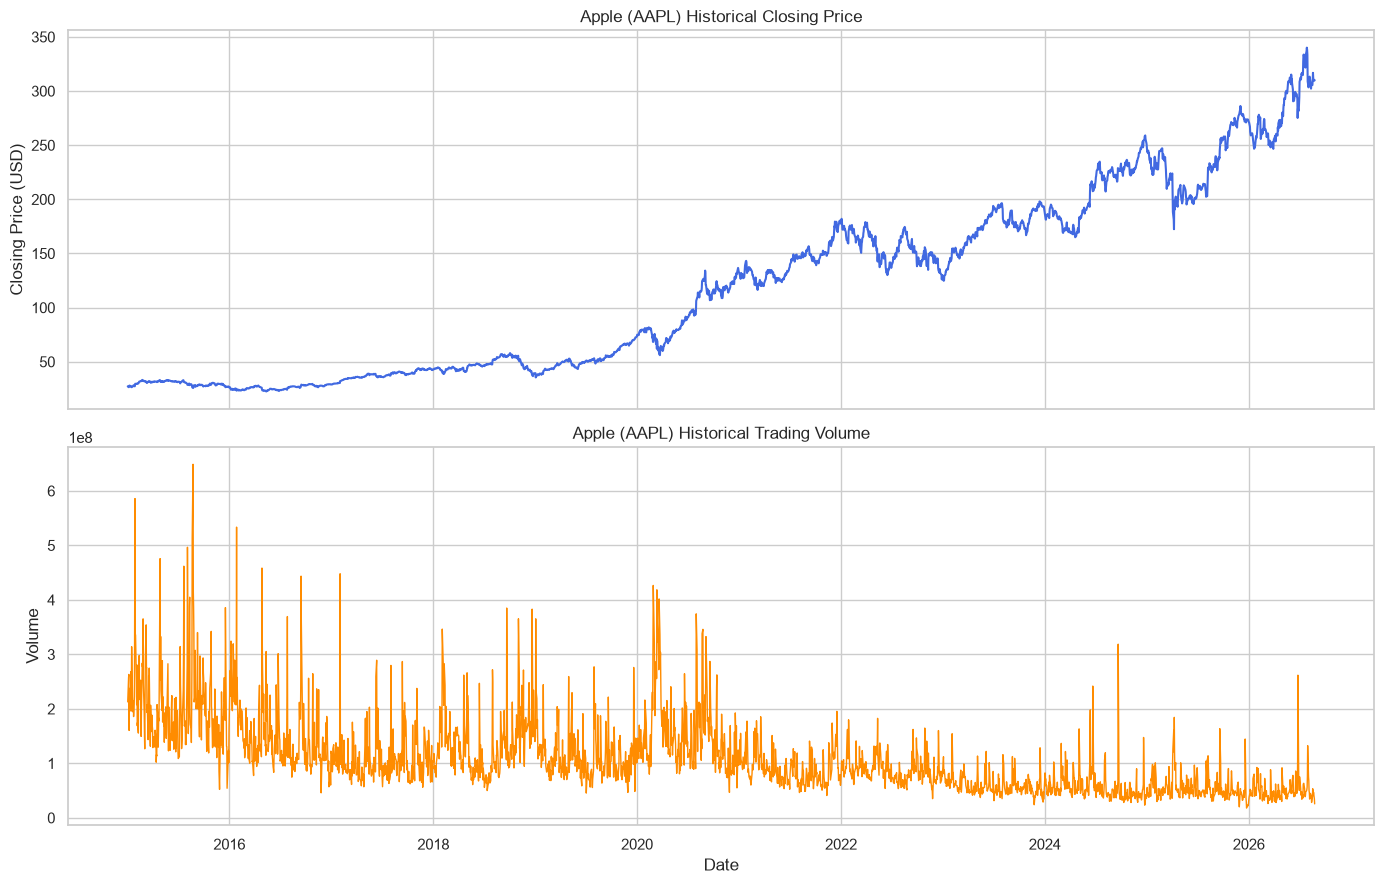

Graph saved to: c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\outputs\figures\aapl_market_overview.png


In [5]:
# Visualize Apple's closing price and trading volume
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(
    market_data["Date"],
    market_data["Close"],
    color="royalblue",
    linewidth=1.5
)
axes[0].set_title("Apple (AAPL) Historical Closing Price")
axes[0].set_ylabel("Closing Price (USD)")

axes[1].plot(
    market_data["Date"],
    market_data["Volume"],
    color="darkorange",
    linewidth=1
)
axes[1].set_title("Apple (AAPL) Historical Trading Volume")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Volume")

plt.tight_layout()

# Save the graph
figure_file = project_root / "outputs" / "figures" / "aapl_market_overview.png"
figure_file.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(figure_file, dpi=300, bbox_inches="tight")

plt.show()
print("Graph saved to:", figure_file)

In [6]:
# Store the following trading day's closing price
market_data["Next_Close"] = market_data["Close"].shift(-1)

# Create the target:
# 1 = price increases the next trading day
# 0 = price stays the same or decreases
market_data["Target"] = np.where(
    market_data["Next_Close"].isna(),
    np.nan,
    (market_data["Next_Close"] > market_data["Close"]).astype(int)
)

# Remove the final row because its next-day price is unavailable
market_data = market_data.dropna(subset=["Next_Close"]).copy()
market_data["Target"] = market_data["Target"].astype(int)

# Save the dataset containing the target
target_file = processed_data_dir / "AAPL_market_with_target.csv"
market_data.to_csv(target_file, index=False)

print("Dataset shape:", market_data.shape)
print("\nTarget distribution:")
print(market_data["Target"].value_counts())

print("\nTarget percentages:")
print((market_data["Target"].value_counts(normalize=True) * 100).round(2))

print("\nSaved to:", target_file)

display(market_data[["Date", "Close", "Next_Close", "Target"]].head())

Dataset shape: (2927, 9)

Target distribution:
Target
1    1552
0    1375
Name: count, dtype: int64

Target percentages:
Target
1    53.02
0    46.98
Name: proportion, dtype: float64

Saved to: c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\data\processed\AAPL_market_with_target.csv


,Date,Close,Next_Close,Target
0,2015-01-02,27.332500,26.562500,0
1,2015-01-05,26.562500,26.565001,1
2,2015-01-06,26.565001,26.937500,1
3,2015-01-07,26.937500,27.972500,1
4,2015-01-08,27.972500,28.002501,1


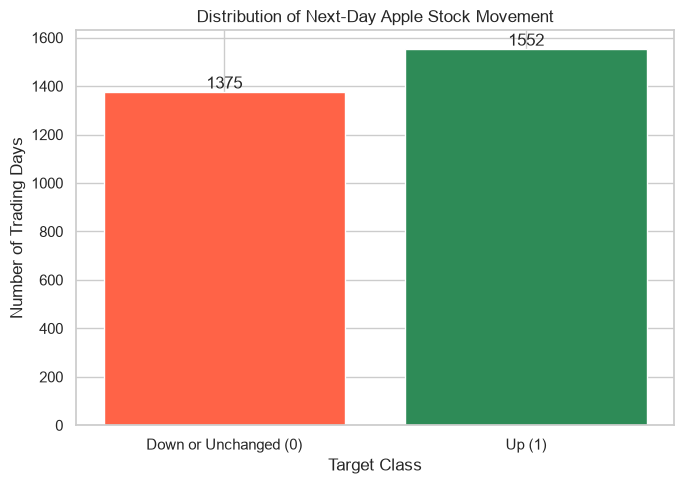

Graph saved to: c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\outputs\figures\aapl_target_distribution.png


In [7]:
# Count the two target classes
target_counts = market_data["Target"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Down or Unchanged (0)", "Up (1)"],
    target_counts.values,
    color=["tomato", "seagreen"]
)

plt.title("Distribution of Next-Day Apple Stock Movement")
plt.xlabel("Target Class")
plt.ylabel("Number of Trading Days")

# Display counts above the bars
for bar, count in zip(bars, target_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        str(count),
        ha="center"
    )

plt.tight_layout()

target_figure_file = (
    project_root / "outputs" / "figures" / "aapl_target_distribution.png"
)
plt.savefig(target_figure_file, dpi=300, bbox_inches="tight")

plt.show()
print("Graph saved to:", target_figure_file)

In [8]:
# Create a separate dataframe for feature engineering
feature_data = market_data.copy()

# Price and volume features
feature_data["Daily_Return"] = feature_data["Close"].pct_change()
feature_data["Price_Range"] = (
    feature_data["High"] - feature_data["Low"]
) / feature_data["Close"]
feature_data["Open_Close_Change"] = (
    feature_data["Close"] - feature_data["Open"]
) / feature_data["Open"]
feature_data["Volume_Change"] = feature_data["Volume"].pct_change()

# Lag features
feature_data["Close_Lag_1"] = feature_data["Close"].shift(1)
feature_data["Return_Lag_1"] = feature_data["Daily_Return"].shift(1)
feature_data["Return_Lag_2"] = feature_data["Daily_Return"].shift(2)
feature_data["Return_Lag_3"] = feature_data["Daily_Return"].shift(3)

# Moving averages
feature_data["MA_5"] = feature_data["Close"].rolling(window=5).mean()
feature_data["MA_10"] = feature_data["Close"].rolling(window=10).mean()
feature_data["MA_20"] = feature_data["Close"].rolling(window=20).mean()

# Exponential moving averages and MACD
feature_data["EMA_12"] = feature_data["Close"].ewm(
    span=12, adjust=False
).mean()
feature_data["EMA_26"] = feature_data["Close"].ewm(
    span=26, adjust=False
).mean()
feature_data["MACD"] = (
    feature_data["EMA_12"] - feature_data["EMA_26"]
)

# Ten-day volatility
feature_data["Volatility_10"] = (
    feature_data["Daily_Return"].rolling(window=10).std()
)

# Relative Strength Index (RSI)
price_change = feature_data["Close"].diff()
average_gain = price_change.clip(lower=0).rolling(window=14).mean()
average_loss = (-price_change.clip(upper=0)).rolling(window=14).mean()

relative_strength = average_gain / average_loss
feature_data["RSI_14"] = 100 - (
    100 / (1 + relative_strength)
)

# Remove values created by percentage-change and rolling calculations
feature_data.replace([np.inf, -np.inf], np.nan, inplace=True)
feature_data.dropna(inplace=True)
feature_data.reset_index(drop=True, inplace=True)

# Save the feature-engineered market dataset
market_features_file = (
    processed_data_dir / "AAPL_market_features.csv"
)
feature_data.to_csv(market_features_file, index=False)

print("Feature-engineered dataset shape:", feature_data.shape)
print("Remaining missing values:", feature_data.isnull().sum().sum())
print("Saved to:", market_features_file)

display(
    feature_data[
        [
            "Date",
            "Close",
            "Daily_Return",
            "MA_5",
            "MA_20",
            "MACD",
            "RSI_14",
            "Target"
        ]
    ].head()
)

Feature-engineered dataset shape: (2908, 25)
Remaining missing values: 0
Saved to: c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\data\processed\AAPL_market_features.csv


,Date,Close,Daily_Return,MA_5,MA_20,MACD,RSI_14,Target
0,2015-01-30,29.290001,-0.014634,28.6805,27.660375,0.427722,58.434328,1
1,2015-02-02,29.657499,0.012547,28.9570,27.776625,0.508972,66.039668,1
2,2015-02-03,29.662500,0.000169,29.4325,27.931625,0.567227,64.899258,1
3,2015-02-04,29.889999,0.007670,29.6450,28.097875,0.624553,66.956211,1
4,2015-02-05,29.985001,0.003178,29.6970,28.250250,0.669927,75.057301,0


In [9]:
# Locate the financial-news sentiment dataset
news_file = raw_data_dir / "all-data.csv"

# The file has no header and uses Latin-1 text encoding
news_data = pd.read_csv(
    news_file,
    encoding="latin-1",
    header=None,
    names=["Sentiment", "Headline"]
)

print("News dataset shape:", news_data.shape)

print("\nMissing values:")
print(news_data.isnull().sum())

print("\nDuplicate rows:", news_data.duplicated().sum())

print("\nSentiment distribution:")
print(news_data["Sentiment"].value_counts())

display(news_data.head())

News dataset shape: (4846, 2)

Missing values:
Sentiment    0
Headline     0
dtype: int64

Duplicate rows: 6

Sentiment distribution:
Sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64


,Sentiment,Headline
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [10]:
import re

# Create a separate copy for preprocessing
news_clean = news_data.copy()

# Standardize sentiment labels
news_clean["Sentiment"] = (
    news_clean["Sentiment"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Remove exact duplicate rows
news_clean.drop_duplicates(inplace=True)

# Function for cleaning headline text
def clean_headline(text):
    text = str(text).lower().strip()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s%$.-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

news_clean["Clean_Headline"] = (
    news_clean["Headline"].apply(clean_headline)
)

# Remove empty and repeated cleaned headlines
news_clean = news_clean[
    news_clean["Clean_Headline"].str.len() > 0
]
news_clean.drop_duplicates(
    subset=["Clean_Headline"],
    keep="first",
    inplace=True
)

# Convert sentiment labels into numerical scores
sentiment_score_map = {
    "negative": -1,
    "neutral": 0,
    "positive": 1
}

news_clean["Sentiment_Score"] = (
    news_clean["Sentiment"].map(sentiment_score_map)
)

# Keep only valid sentiment records
news_clean.dropna(subset=["Sentiment_Score"], inplace=True)
news_clean["Sentiment_Score"] = (
    news_clean["Sentiment_Score"].astype(int)
)
news_clean.reset_index(drop=True, inplace=True)

# Save the cleaned dataset
clean_news_file = (
    processed_data_dir / "financial_news_clean.csv"
)
news_clean.to_csv(clean_news_file, index=False)

print("Cleaned news shape:", news_clean.shape)
print("Remaining missing values:", news_clean.isnull().sum().sum())
print("Remaining duplicate headlines:",
      news_clean["Clean_Headline"].duplicated().sum())

print("\nSentiment distribution:")
print(news_clean["Sentiment"].value_counts())

print("\nSaved to:", clean_news_file)

display(
    news_clean[
        ["Headline", "Clean_Headline", "Sentiment", "Sentiment_Score"]
    ].head()
)

Cleaned news shape: (4835, 4)
Remaining missing values: 0
Remaining duplicate headlines: 0

Sentiment distribution:
Sentiment
neutral     2869
positive    1362
negative     604
Name: count, dtype: int64

Saved to: c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\data\processed\financial_news_clean.csv


,Headline,Clean_Headline,Sentiment,Sentiment_Score
0,"According to Gran , the company has no plans t...",according to gran the company has no plans to ...,neutral,0
1,Technopolis plans to develop in stages an area...,technopolis plans to develop in stages an area...,neutral,0
2,The international electronic industry company ...,the international electronic industry company ...,negative,-1
3,With the new production plant the company woul...,with the new production plant the company woul...,positive,1
4,According to the company 's updated strategy f...,according to the company s updated strategy fo...,positive,1
